# Practical Considerations for Deep Learning

The previous notebook built the mechanics of neural networks from scratch. This notebook is about what happens when you try to train one on a real problem and it doesn't work. For additional advice, see this excellent [blog post](https://karpathy.github.io/2019/04/25/recipe/) by Andrej Karpathy.

We use the **Leaf River basin dataset** — 30 years of daily precipitation, temperature, and streamflow — as our running example. Every concept is demonstrated on the same real data, so you can see how each technique improves a working hydrology model rather than a toy example.

We focus on eight issues that come up in almost every project:

1. **Data normalization** — why unnormalized inputs silently break training
2. **Reading loss curves** — the core diagnostic tool
3. **Overfitting and regularization** — weight decay, dropout, early stopping
4. **Earth science pitfalls** — temporal data leakage and what to do instead
5. **Class imbalance** — when rare events dominate what you care about
6. **Learning rate schedules** — adaptive learning rates for stable convergence
7. **Gradient clipping** — preventing exploding gradients
8. **Batch normalization** — stabilizing deep networks

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

rng = np.random.default_rng(42)
torch.manual_seed(42)

# ── Leaf River dataset (30 years, daily) ─────────────────────────────────────
data       = pd.read_csv('../../data/LeafRiverDaily.csv')
precip     = data['Precipitation'].values.astype(np.float32)  # mm/day
temp       = data['Temperature'].values.astype(np.float32)    # °C
streamflow = data['Streamflow'].values.astype(np.float32)     # mm/day
N = len(precip)
print(f"Leaf River: {N} daily observations ({N/365.25:.1f} years)")
print(f"Precipitation — mean {precip.mean():.2f}, max {precip.max():.1f} mm/day")
print(f"Temperature   — mean {temp.mean():.2f}, range [{temp.min():.1f}, {temp.max():.1f}] °C")
print(f"Streamflow    — mean {streamflow.mean():.2f}, max {streamflow.max():.1f} mm/day")

# ── Lag-embedding helper (same as notebook 1) ─────────────────────────────────
def create_lag_features(P, T, Q, lag_p=7, lag_t=7):
    """Stack lag_p days of P and lag_t days of T into a feature vector."""
    max_lag = max(lag_p, lag_t)
    n = len(P) - max_lag
    X = np.zeros((n, lag_p + lag_t), dtype=np.float32)
    for i in range(lag_p):
        X[:, i] = P[max_lag - i : len(P) - i]
    for i in range(lag_t):
        X[:, lag_p + i] = T[max_lag - i : len(T) - i]
    return X, Q[max_lag:].astype(np.float32)

# Default 7-day lag embedding used throughout this notebook
lag_p, lag_t = 7, 7
X_lag, y_lag = create_lag_features(precip, temp, streamflow, lag_p, lag_t)
n_features   = lag_p + lag_t

# ── Temporal split: 70 % train / 30 % val ────────────────────────────────────
n_train = int(0.7 * len(X_lag))
X_tr_raw, X_vl_raw = X_lag[:n_train], X_lag[n_train:]
y_tr_raw, y_vl_raw = y_lag[:n_train], y_lag[n_train:]

# Standardize using training statistics only (avoids data leakage)
X_mu  = X_tr_raw.mean(axis=0)
X_sig = X_tr_raw.std(axis=0) + 1e-8
X_tr  = (X_tr_raw - X_mu) / X_sig
X_vl  = (X_vl_raw - X_mu) / X_sig

y_mu  = y_tr_raw.mean()
y_sig = y_tr_raw.std()
y_tr_norm = (y_tr_raw - y_mu) / y_sig
y_vl_norm = (y_vl_raw - y_mu) / y_sig

print(f"\nLag feature matrix: {X_lag.shape[0]} samples × {n_features} features")
print(f"Train: {n_train},  Val: {len(X_vl_raw)}")

Leaf River: 10960 daily observations (30.0 years)
Precipitation — mean 3.87, max 221.5 mm/day
Temperature   — mean 2.91, range [0.0, 8.5] °C
Streamflow    — mean 1.34, max 64.0 mm/day

Lag feature matrix: 10953 samples × 14 features
Train: 7667,  Val: 3286


## 1. Data Normalization

Neural networks learn by gradient descent. If one input feature has values in $[0, 221]$ (precipitation in mm/day) and another in $[0, 8.5]$ (temperature in °C), the gradient signal for the large-scale feature dominates and the small-scale feature's weights barely update.

The standard fix is **standardization**: subtract the mean and divide by the standard deviation,

$$\tilde{x} = \frac{x - \mu}{\sigma}$$

so every feature has zero mean and unit variance at the network's input.

**Critical rule:** compute $\mu$ and $\sigma$ on the *training set only*, then apply the same transform to validation and test sets. Computing statistics on the full dataset is a form of data leakage.

We compare training a next-day streamflow prediction model on raw vs. standardized precipitation and temperature inputs.

In [2]:
# Use (P(t), T(t)) as a 2-feature input to predict Q(t+1).
# Precipitation spans [0, 221] mm/day; temperature spans [0, 8.5] °C.
# The 26× scale difference between features demonstrates the normalization problem.

X2_raw = np.column_stack([precip[:-1], temp[:-1]])   # shape (N-1, 2)
y2     = streamflow[1:].reshape(-1, 1)                # next-day streamflow

n2_train = int(0.7 * len(X2_raw))
X2_tr_raw = X2_raw[:n2_train].astype(np.float32)
X2_vl_raw = X2_raw[n2_train:].astype(np.float32)
y2_tr = y2[:n2_train].astype(np.float32)
y2_vl = y2[n2_train:].astype(np.float32)

# Training-set statistics only
mu2    = X2_tr_raw.mean(axis=0)
sigma2 = X2_tr_raw.std(axis=0) + 1e-8
X2_tr  = (X2_tr_raw - mu2) / sigma2
X2_vl  = (X2_vl_raw - mu2) / sigma2

print("Feature ranges (raw inputs):")
print(f"  Precipitation: [{X2_tr_raw[:,0].min():.1f}, {X2_tr_raw[:,0].max():.1f}] mm/day")
print(f"  Temperature:   [{X2_tr_raw[:,1].min():.2f}, {X2_tr_raw[:,1].max():.2f}] °C")
print("\nFeature ranges (after standardization):")
print(f"  Precipitation: [{X2_tr[:,0].min():.2f}, {X2_tr[:,0].max():.2f}]")
print(f"  Temperature:   [{X2_tr[:,1].min():.2f}, {X2_tr[:,1].max():.2f}]")

Feature ranges (raw inputs):
  Precipitation: [0.0, 135.0] mm/day
  Temperature:   [0.00, 8.50] °C

Feature ranges (after standardization):
  Precipitation: [-0.38, 13.50]
  Temperature:   [-1.55, 2.93]


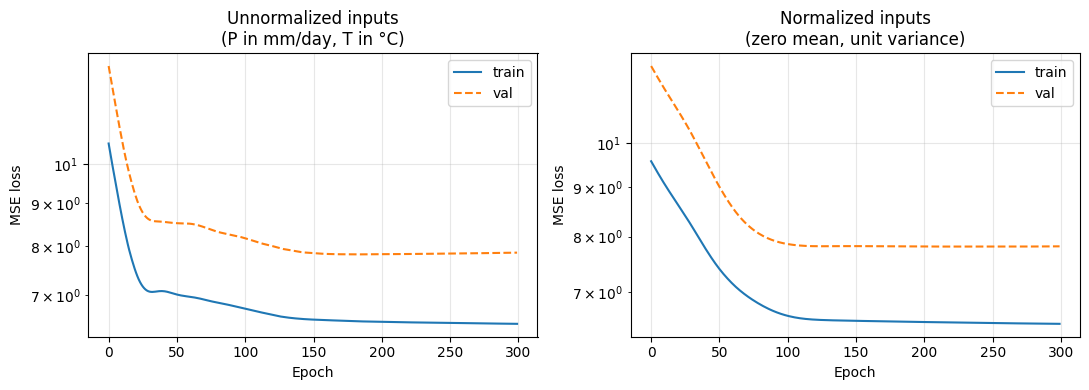

In [3]:
def make_mlp2(in_features=2, hidden=32):
    return nn.Sequential(
        nn.Linear(in_features, hidden), nn.ReLU(),
        nn.Linear(hidden, hidden),       nn.ReLU(),
        nn.Linear(hidden, 1)
    )

def train2(model, X_tr, y_tr, X_vl, y_vl, epochs=300, lr=1e-3):
    opt     = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    Xt = torch.tensor(X_tr); yt = torch.tensor(y_tr)
    Xv = torch.tensor(X_vl); yv = torch.tensor(y_vl)
    tr_losses, vl_losses = [], []
    for _ in range(epochs):
        model.train(); opt.zero_grad()
        l = loss_fn(model(Xt), yt); l.backward(); opt.step()
        with torch.no_grad():
            model.eval()
            tr_losses.append(l.item())
            vl_losses.append(loss_fn(model(Xv), yv).item())
    return tr_losses, vl_losses

torch.manual_seed(0)
model_raw  = make_mlp2()
model_norm = make_mlp2()
model_norm.load_state_dict(model_raw.state_dict())   # identical starting weights

losses_raw  = train2(model_raw,  X2_tr_raw, y2_tr, X2_vl_raw, y2_vl)
losses_norm = train2(model_norm, X2_tr,     y2_tr, X2_vl,     y2_vl)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (tr, vl), title in zip(axes,
        [losses_raw, losses_norm],
        ['Unnormalized inputs\n(P in mm/day, T in °C)',
         'Normalized inputs\n(zero mean, unit variance)']):
    ax.plot(tr, label='train')
    ax.plot(vl, label='val', linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE loss')
    ax.set_yscale('log')
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Precipitation ranges from 0 to 221 mm/day while temperature spans only 0 to 8.5 °C. On the raw scale, precipitation dominates the gradient signal and temperature's weights barely update — the model essentially ignores temperature even though it carries seasonal information. After standardization, both features contribute equally to training.

This matters especially for intermittent variables like precipitation: most days have zero rain, so the non-zero events create large, infrequent gradient spikes that destabilize training on the raw scale. Normalizing dampens this effect and produces smooth, fast convergence.

Normalizing inputs is one of the highest-leverage things you can do before touching architecture or learning rate.

## 2. Reading Loss Curves

The training loss and validation loss plotted together tell you almost everything about what is going wrong.

| Pattern | Diagnosis | Fix |
|---|---|---|
| Both losses high and flat | Underfitting / learning rate too small | Bigger model, higher LR |
| Train loss falls, val loss stalls or rises | Overfitting | Regularize, get more data |
| Loss oscillates wildly | Learning rate too large | Lower LR or add gradient clipping |
| Loss explodes (NaN) | Vanishing/exploding gradients or bad init | Gradient clipping, normalization layers |
| Train ≈ val, both low | Good | Ship it |

### Sanity check: overfit a single batch

Before any full training run, take a single mini-batch and check that your model can overfit it to near-zero loss. If it cannot, something is fundamentally broken (wrong loss function, bad architecture, bug in the data pipeline). This takes 30 seconds and saves hours.

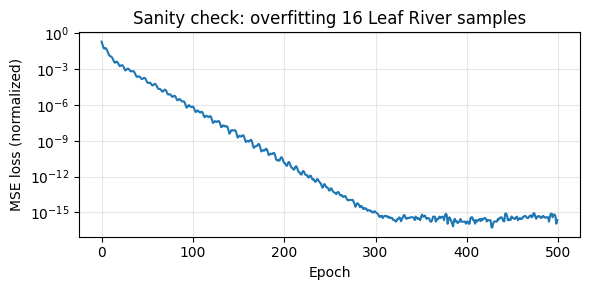

Final loss on 16 samples: 0.0000


In [4]:
# Sanity check: can we overfit 16 Leaf River samples?
torch.manual_seed(1)
tiny_model = nn.Sequential(
    nn.Linear(n_features, 32), nn.ReLU(),
    nn.Linear(32, 32),         nn.ReLU(),
    nn.Linear(32, 1)
)
Xt_tiny = torch.tensor(X_tr[:16])
yt_tiny = torch.tensor(y_tr_norm[:16]).reshape(-1, 1)

opt     = torch.optim.Adam(tiny_model.parameters(), lr=1e-2)
loss_fn = nn.MSELoss()
losses_tiny = []
for _ in range(500):
    opt.zero_grad()
    l = loss_fn(tiny_model(Xt_tiny), yt_tiny)
    l.backward(); opt.step()
    losses_tiny.append(l.item())

plt.figure(figsize=(6, 3))
plt.plot(losses_tiny)
plt.xlabel('Epoch'); plt.ylabel('MSE loss (normalized)')
plt.title('Sanity check: overfitting 16 Leaf River samples')
plt.yscale('log'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Final loss on 16 samples: {losses_tiny[-1]:.4f}")

Loss drives toward zero — the model and loss function are working correctly. Now we can confidently move to the full dataset and expect any remaining issues to be about generalization, not correctness.

## 3. Overfitting and Regularization

A network with enough parameters can memorize the training set. Overfitting shows up as a growing gap between training and validation loss.

We demonstrate with a deliberately difficult setup: we restrict the Leaf River training set to **300 samples** out of 7600+ available days. The model has more than enough capacity to memorize this limited window, making overfitting easy to induce.

### Three standard fixes

1. **Weight decay** — adds $\lambda \|\theta\|^2$ to the loss, penalizing large weights. In PyTorch: `optimizer = Adam(..., weight_decay=λ)`.
2. **Dropout** — randomly zeroes $p$ fraction of activations during training, forcing redundant representations. Disabled at inference with `model.eval()`.
3. **Early stopping** — monitor validation loss; restore the checkpoint at the best epoch.

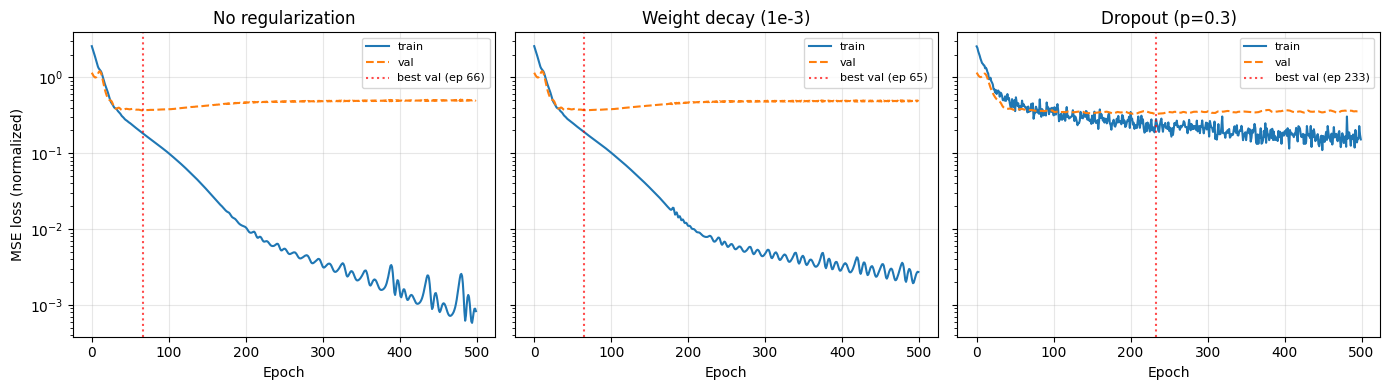

In [5]:
# Deliberately restricted: only 300 of 7600+ training days
N_small = 300
Xtr_s = torch.tensor(X_tr[:N_small])
ytr_s = torch.tensor(y_tr_norm[:N_small]).reshape(-1, 1)
Xvl_s = torch.tensor(X_vl)
yvl_s = torch.tensor(y_vl_norm).reshape(-1, 1)

def big_mlp_leaf(dropout_p=0.0):
    """Over-parameterised 3-hidden-layer MLP relative to N_small=300."""
    layers = [nn.Linear(n_features, 128), nn.ReLU()]
    if dropout_p > 0:
        layers.append(nn.Dropout(dropout_p))
    for _ in range(2):
        layers += [nn.Linear(128, 128), nn.ReLU()]
        if dropout_p > 0:
            layers.append(nn.Dropout(dropout_p))
    layers.append(nn.Linear(128, 1))
    return nn.Sequential(*layers)

def run_experiment(model, weight_decay=0.0, epochs=500):
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()
    tr_hist, vl_hist = [], []
    best_val, best_ep = float('inf'), 0
    for ep in range(epochs):
        model.train(); opt.zero_grad()
        l = loss_fn(model(Xtr_s), ytr_s); l.backward(); opt.step()
        with torch.no_grad():
            model.eval()
            vl = loss_fn(model(Xvl_s), yvl_s).item()
        tr_hist.append(l.item()); vl_hist.append(vl)
        if vl < best_val:
            best_val, best_ep = vl, ep
    return tr_hist, vl_hist, best_ep

torch.manual_seed(0); m_base = big_mlp_leaf()
torch.manual_seed(0); m_wd   = big_mlp_leaf()
torch.manual_seed(0); m_drop = big_mlp_leaf(dropout_p=0.3)

tr0, vl0, ep0 = run_experiment(m_base, weight_decay=0.0)
tr1, vl1, ep1 = run_experiment(m_wd,   weight_decay=1e-3)
tr2, vl2, ep2 = run_experiment(m_drop)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
configs = [(tr0, vl0, ep0, 'No regularization'),
           (tr1, vl1, ep1, 'Weight decay (1e-3)'),
           (tr2, vl2, ep2, 'Dropout (p=0.3)')]
for ax, (tr, vl, ep, title) in zip(axes, configs):
    ax.plot(tr, label='train')
    ax.plot(vl, label='val', linestyle='--')
    ax.axvline(ep, color='red', linestyle=':', alpha=0.7, label=f'best val (ep {ep})')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_yscale('log')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
axes[0].set_ylabel('MSE loss (normalized)')
plt.tight_layout()
plt.show()

### What we see

- **No regularization:** train loss drives to near-zero while val loss rises — the model memorizes 300 streamflow samples rather than learning the underlying P–T–Q relationship.
- **Weight decay:** penalizes large weights, keeping the model from fitting the noise. Val loss stays lower and more stable.
- **Dropout:** randomly zeroes activations during training, forcing redundant representations. The red line marks the best validation epoch — you would load those weights in practice (**early stopping**).

In practice, weight decay and early stopping are almost always used together. Dropout is more common in very large models.

## 4. Earth Science Pitfall: Temporal Data Leakage

In Earth science, our data almost always has temporal structure. If you randomly shuffle samples into train and validation sets, you introduce **data leakage**: the model has seen the future during training (via nearby time steps with high autocorrelation), and the validation score is optimistically biased.

**The correct approach is a temporal split**: train on the past, validate/test on the future.

### A concrete demonstration on Leaf River

Streamflow is highly autocorrelated — today's flow is strongly correlated with yesterday's. A random split puts adjacent days in both train and val sets, so the model can "interpolate" between near-identical samples rather than learning to predict the future.

We compare random shuffling vs. a proper temporal split, measuring Nash–Sutcliffe Efficiency (NSE) on the validation set.

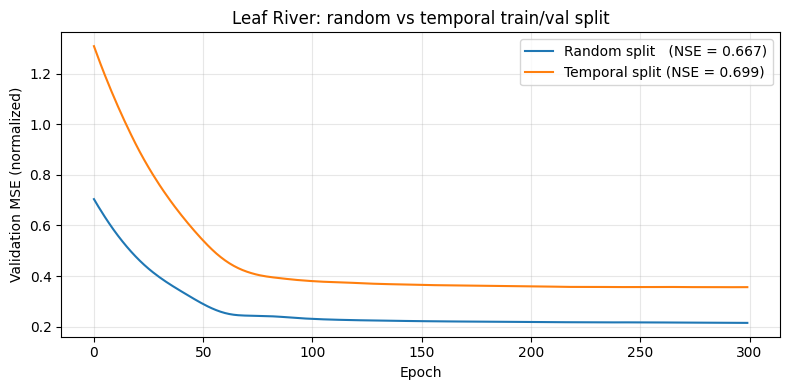

Random split  NSE: 0.667  ← optimistically biased (future autocorrelation leaks in)
Temporal split NSE: 0.699 ← honest estimate on future data


In [6]:
def nse(y_true, y_pred):
    """Nash-Sutcliffe Efficiency: 1 = perfect, 0 = mean baseline, <0 = worse than mean."""
    return 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)

def eval_split(idx_tr, idx_vl):
    Xtr_s = torch.tensor(X_lag[idx_tr])
    ytr_s = torch.tensor(y_lag[idx_tr])
    Xvl_s = torch.tensor(X_lag[idx_vl])
    yvl_s = torch.tensor(y_lag[idx_vl])

    # Normalize using train indices only
    xmu  = Xtr_s.mean(0, keepdim=True)
    xsig = Xtr_s.std(0,  keepdim=True) + 1e-8
    ymu  = ytr_s.mean().item()
    ysig = ytr_s.std().item()

    Xtr_n = (Xtr_s - xmu) / xsig
    Xvl_n = (Xvl_s - xmu) / xsig
    ytr_n = ((ytr_s - ymu) / ysig).reshape(-1, 1)
    yvl_n = ((yvl_s - ymu) / ysig).reshape(-1, 1)

    torch.manual_seed(0)
    m = nn.Sequential(nn.Linear(n_features, 32), nn.ReLU(),
                      nn.Linear(32, 32),          nn.ReLU(),
                      nn.Linear(32, 1))
    opt     = torch.optim.Adam(m.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()
    val_hist = []
    for _ in range(300):
        m.train(); opt.zero_grad()
        loss_fn(m(Xtr_n), ytr_n).backward(); opt.step()
        with torch.no_grad():
            m.eval(); val_hist.append(loss_fn(m(Xvl_n), yvl_n).item())

    m.eval()
    with torch.no_grad():
        y_pred = m(Xvl_n).numpy().flatten() * ysig + ymu
    return val_hist, nse(yvl_s.numpy(), y_pred)

n_lag    = len(X_lag)
n_tr_lag = int(0.7 * n_lag)

# Approach 1: random shuffle (WRONG for time series)
shuffle_idx = rng.permutation(n_lag)
idx_tr_rand, idx_vl_rand = shuffle_idx[:n_tr_lag], shuffle_idx[n_tr_lag:]

# Approach 2: temporal split (CORRECT)
idx_tr_temp = np.arange(n_tr_lag)
idx_vl_temp = np.arange(n_tr_lag, n_lag)

vl_rand, nse_rand = eval_split(idx_tr_rand, idx_vl_rand)
vl_temp, nse_temp = eval_split(idx_tr_temp, idx_vl_temp)

plt.figure(figsize=(8, 4))
plt.plot(vl_rand, label=f'Random split   (NSE = {nse_rand:.3f})', color='C0')
plt.plot(vl_temp, label=f'Temporal split (NSE = {nse_temp:.3f})', color='C1')
plt.xlabel('Epoch'); plt.ylabel('Validation MSE (normalized)')
plt.title('Leaf River: random vs temporal train/val split')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Random split  NSE: {nse_rand:.3f}  ← optimistically biased (future autocorrelation leaks in)")
print(f"Temporal split NSE: {nse_temp:.3f} ← honest estimate on future data")

The random split reports an artificially high NSE because adjacent time steps leak across the train/val boundary. Streamflow is autocorrelated at lags of days to weeks, so "predicting" a day that is surrounded by training samples is much easier than predicting the future.

The temporal split gives a realistic estimate of how the model will perform on unseen future data — which is what matters for operational hydrology applications like flood forecasting and water resources planning.

**Rule:** for any time-series dataset in Earth science (climate, hydrology, seismology), always split chronologically. Never shuffle.

---
## 5. Handling Class Imbalance

In Earth science, the events we care most about are often the rarest. Flood events, extreme precipitation, heatwaves, and droughts are all low-frequency, high-impact phenomena.

When training a binary classifier on imbalanced data, a naive network achieves high accuracy by always predicting the majority class — but misses every event that matters.

### High-flow detection in the Leaf River

We define a **high-flow event** as any day where streamflow exceeds the 95th percentile (Q95 ≈ top 5% of days). Our goal: given the past 7 days of precipitation and temperature, predict whether today is a high-flow event.

This is a real forecasting problem — early warning of high flows allows dam operators and emergency managers to prepare.

**Three standard fixes:**

1. **Weighted loss** — penalize mistakes on the minority class more heavily (`pos_weight ≈ N_negative / N_positive`)
2. **Resampling** — oversample the minority class or undersample the majority
3. **Focal loss** — down-weight easy examples, focus on hard negatives

High-flow threshold (Q95): 5.39 mm/day
High-flow days: 548 / 10953 (5.0%)

Training set: 336 high-flow days / 7667 total
Recommended pos_weight = 7331/336 ≈ 22


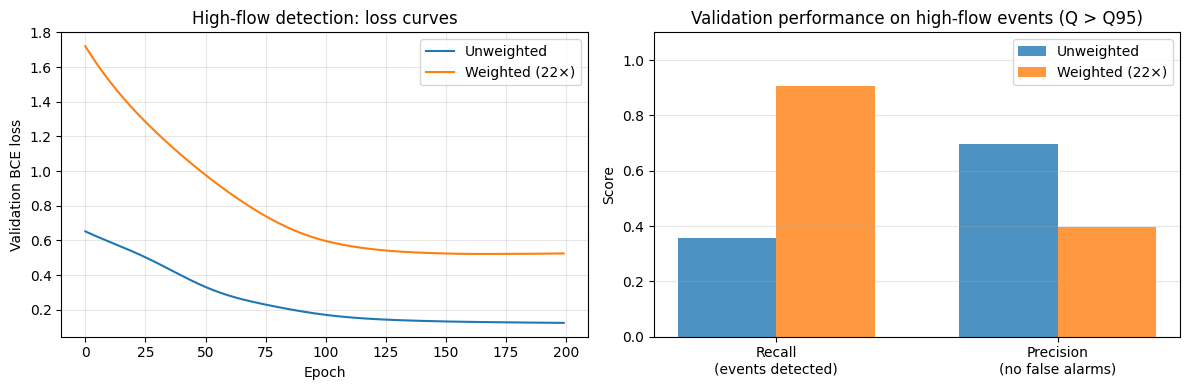


Unweighted — Recall: 0.36, Precision: 0.70
Weighted   — Recall: 0.91, Precision: 0.40


In [7]:
# Define "high-flow" events: streamflow above the 95th percentile
q95 = np.percentile(y_lag, 95)
print(f"High-flow threshold (Q95): {q95:.2f} mm/day")
print(f"High-flow days: {(y_lag > q95).sum()} / {len(y_lag)} ({100*(y_lag > q95).mean():.1f}%)")

# Binary target: 1 = high-flow event
y_cls = (y_lag > q95).astype(np.float32)

# Temporal split to avoid leakage from autocorrelated streamflow
n_tr_cls     = int(0.7 * len(X_lag))
X_tr_cls_raw = X_lag[:n_tr_cls]
X_vl_cls_raw = X_lag[n_tr_cls:]
y_tr_cls     = y_cls[:n_tr_cls].reshape(-1, 1)
y_vl_cls     = y_cls[n_tr_cls:].reshape(-1, 1)

# Normalize features using training stats only
xmu_c  = X_tr_cls_raw.mean(0)
xsig_c = X_tr_cls_raw.std(0) + 1e-8
Xt_cls = torch.tensor((X_tr_cls_raw - xmu_c) / xsig_c)
Xv_cls = torch.tensor((X_vl_cls_raw - xmu_c) / xsig_c)
yt_cls = torch.tensor(y_tr_cls)
yv_cls = torch.tensor(y_vl_cls)

n_neg = (yt_cls == 0).sum().item()
n_pos = (yt_cls == 1).sum().item()
auto_weight = n_neg / n_pos
print(f"\nTraining set: {int(n_pos)} high-flow days / {int(n_neg + n_pos)} total")
print(f"Recommended pos_weight = {n_neg:.0f}/{n_pos:.0f} ≈ {auto_weight:.0f}")

def train_cls(pos_weight=1.0, epochs=200):
    torch.manual_seed(0)
    model = nn.Sequential(
        nn.Linear(n_features, 32), nn.ReLU(),
        nn.Linear(32, 32),         nn.ReLU(),
        nn.Linear(32, 1)
    )
    opt     = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]))
    val_losses = []
    for _ in range(epochs):
        model.train(); opt.zero_grad()
        loss_fn(model(Xt_cls), yt_cls).backward(); opt.step()
        with torch.no_grad():
            model.eval()
            val_losses.append(loss_fn(model(Xv_cls), yv_cls).item())
    return model, val_losses

model_unw, vl_unw = train_cls(pos_weight=1.0)
model_wgt, vl_wgt = train_cls(pos_weight=auto_weight)

with torch.no_grad():
    pred_unw = (torch.sigmoid(model_unw(Xv_cls)) > 0.5)
    pred_wgt = (torch.sigmoid(model_wgt(Xv_cls)) > 0.5)
    true_pos = yv_cls.bool()

    def perf(pred, tp):
        tp_n = (pred & tp).sum().item()
        fp_n = (pred & ~tp).sum().item()
        fn_n = (~pred & tp).sum().item()
        recall = tp_n / (tp_n + fn_n) if (tp_n + fn_n) > 0 else 0.0
        prec   = tp_n / (tp_n + fp_n) if (tp_n + fp_n) > 0 else 0.0
        return recall, prec

    recall_unw, prec_unw = perf(pred_unw, true_pos)
    recall_wgt, prec_wgt = perf(pred_wgt, true_pos)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(vl_unw, label='Unweighted',              color='C0', linewidth=1.5)
axes[0].plot(vl_wgt, label=f'Weighted ({auto_weight:.0f}×)', color='C1', linewidth=1.5)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Validation BCE loss')
axes[0].set_title('High-flow detection: loss curves')
axes[0].legend(); axes[0].grid(alpha=0.3)

x_pos = np.arange(2); w = 0.35
axes[1].bar(x_pos - w/2, [recall_unw, prec_unw], w, label='Unweighted', color='C0', alpha=0.8)
axes[1].bar(x_pos + w/2, [recall_wgt, prec_wgt], w,
            label=f'Weighted ({auto_weight:.0f}×)', color='C1', alpha=0.8)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(['Recall\n(events detected)', 'Precision\n(no false alarms)'])
axes[1].set_ylim(0, 1.1); axes[1].set_ylabel('Score')
axes[1].set_title('Validation performance on high-flow events (Q > Q95)')
axes[1].legend(); axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

print(f"\nUnweighted — Recall: {recall_unw:.2f}, Precision: {prec_unw:.2f}")
print(f"Weighted   — Recall: {recall_wgt:.2f}, Precision: {prec_wgt:.2f}")

The unweighted model optimizes overall accuracy and ignores the rare high-flow class — it predicts "no high flow" almost everywhere. The weighted model balances recall (catching true events) against precision (avoiding false alarms).

**Rule of thumb**: set `pos_weight ≈ N_negative / N_positive`. For 5% positive class, try `pos_weight ≈ 19`. Then tune based on whether you prioritize recall (don't miss floods) or precision (don't issue false warnings). In operational hydrology, missing a flood is typically far more costly than a false alarm, so recall is usually weighted higher.

---
## 6. Learning Rate Schedules

A fixed learning rate $\eta$ faces a tradeoff: large $\eta$ converges quickly but oscillates near the minimum; small $\eta$ converges slowly but finds a better solution. The fix is to **decay the learning rate during training** — start large to make fast progress, then reduce $\eta$ to fine-tune.

**Three common schedules:**

1. **Step decay** — reduce $\eta$ by a factor every $N$ epochs (e.g., $\eta \leftarrow 0.1\eta$ every 50 epochs)
2. **Cosine annealing** — smooth decay following $\eta(t) = \eta_{\min} + \frac{1}{2}(\eta_{\max} - \eta_{\min})(1 + \cos(\pi t / T))$
3. **ReduceLROnPlateau** — reduce $\eta$ when validation loss stops improving (adaptive, no schedule needed)

We demonstrate on the Leaf River streamflow prediction task.

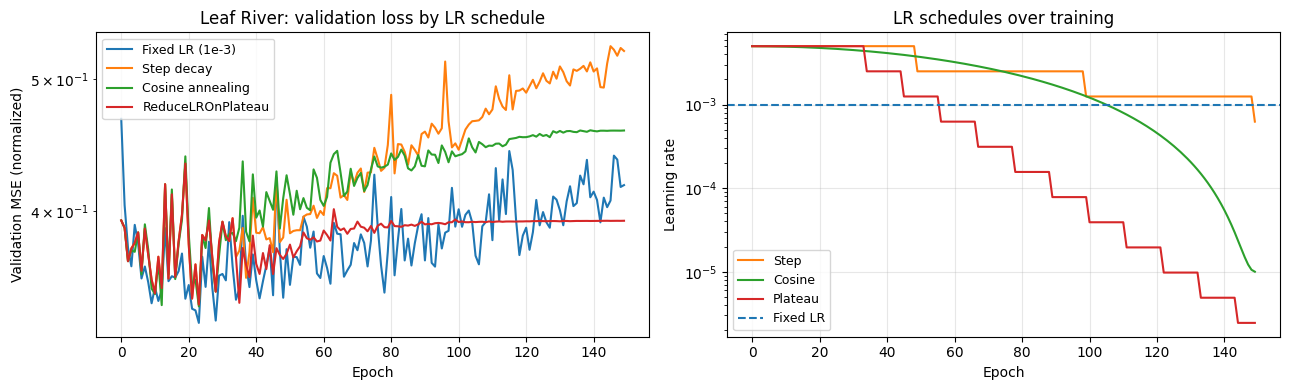

Final validation MSE (normalized):
  none      : 0.41808
  step      : 0.52406
  cosine    : 0.45836
  plateau   : 0.39369


In [8]:
# Leaf River regression task for LR schedule comparison
Xt_lr   = torch.tensor(X_tr)
yt_lr   = torch.tensor(y_tr_norm).reshape(-1, 1)
Xv_lr   = torch.tensor(X_vl)
yv_lr   = torch.tensor(y_vl_norm).reshape(-1, 1)
loader_lr = DataLoader(TensorDataset(Xt_lr, yt_lr), batch_size=128, shuffle=True)

def train_with_schedule(schedule_type='none', epochs=150):
    torch.manual_seed(0)
    model = nn.Sequential(
        nn.Linear(n_features, 64), nn.ReLU(),
        nn.Linear(64, 64),         nn.ReLU(),
        nn.Linear(64, 1)
    )
    lr_init = 1e-3 if schedule_type == 'none' else 5e-3
    opt     = torch.optim.Adam(model.parameters(), lr=lr_init)
    loss_fn = nn.MSELoss()

    if schedule_type == 'step':
        scheduler = torch.optim.lr_scheduler.StepLR(opt, step_size=50, gamma=0.5)
    elif schedule_type == 'cosine':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-5)
    elif schedule_type == 'plateau':
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min',
                                                                factor=0.5, patience=10)
    else:
        scheduler = None

    val_losses, lrs = [], []
    for ep in range(epochs):
        model.train()
        for xb, yb in loader_lr:
            opt.zero_grad(); loss_fn(model(xb), yb).backward(); opt.step()
        with torch.no_grad():
            model.eval()
            vl = loss_fn(model(Xv_lr), yv_lr).item()
        val_losses.append(vl)
        if schedule_type == 'plateau':
            scheduler.step(vl)
        elif scheduler is not None:
            scheduler.step()
        lrs.append(opt.param_groups[0]['lr'])
    return val_losses, lrs

results_lr = {}
for sched in ['none', 'step', 'cosine', 'plateau']:
    results_lr[sched] = train_with_schedule(sched)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for sched, color, label in [('none',    'C0', 'Fixed LR (1e-3)'),
                              ('step',    'C1', 'Step decay'),
                              ('cosine',  'C2', 'Cosine annealing'),
                              ('plateau', 'C3', 'ReduceLROnPlateau')]:
    vl, _ = results_lr[sched]
    axes[0].plot(vl, color=color, linewidth=1.5, label=label)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Validation MSE (normalized)')
axes[0].set_title('Leaf River: validation loss by LR schedule')
axes[0].set_yscale('log'); axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

for sched, color in [('step', 'C1'), ('cosine', 'C2'), ('plateau', 'C3')]:
    _, lrs = results_lr[sched]
    axes[1].plot(lrs, color=color, linewidth=1.5, label=sched.capitalize())
axes[1].axhline(1e-3, color='C0', linewidth=1.5, linestyle='--', label='Fixed LR')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Learning rate')
axes[1].set_title('LR schedules over training')
axes[1].set_yscale('log'); axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print("Final validation MSE (normalized):")
for sched in ['none', 'step', 'cosine', 'plateau']:
    print(f"  {sched:10s}: {results_lr[sched][0][-1]:.5f}")

All three schedules outperform a fixed learning rate. **Cosine annealing** is simple and works well in practice — it smoothly decays from `lr_max` to `lr_min` and requires no manual tuning of step points. **ReduceLROnPlateau** is adaptive and requires no schedule at all, making it a good default choice when you don't know the right decay pattern.

---
## 7. Gradient Clipping

In recurrent networks (RNNs, LSTMs) or deep feedforward networks with many layers, gradients can **explode** — grow exponentially during backpropagation. The loss suddenly jumps to NaN and training collapses.

**Gradient clipping** caps the gradient norm to a maximum value before the optimizer step:

$$
\mathbf{g} \leftarrow \begin{cases}
\mathbf{g} & \text{if } \|\mathbf{g}\| \leq \theta \\
\theta \frac{\mathbf{g}}{\|\mathbf{g}\|} & \text{if } \|\mathbf{g}\| > \theta
\end{cases}
$$

where $\theta$ is the clipping threshold (commonly 1.0 or 5.0).

We demonstrate on an 8-hidden-layer Tanh network trained on the Leaf River data with large initial weights — a scenario that induces gradient explosion. Tanh networks are especially susceptible because the gradient includes a product of $\tanh'(z_i)$ terms, one per layer, and even small deviations from the saturated regime can compound.

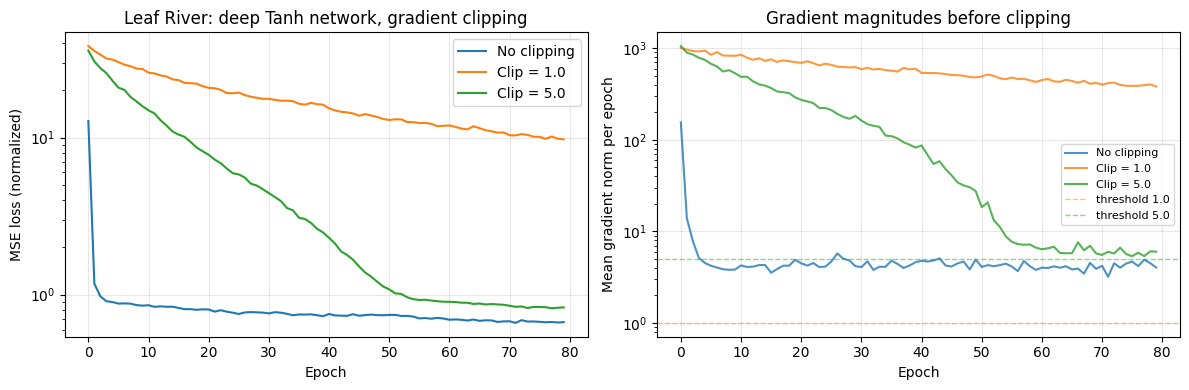

Final MSE — No clipping: 0.6687, Clip 1.0: 9.7417, Clip 5.0: 0.8297


In [9]:
# Deep Tanh network on Leaf River with large init — induces gradient explosion
loader_clip = DataLoader(
    TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr_norm).reshape(-1, 1)),
    batch_size=256, shuffle=True)
Xv_clip = torch.tensor(X_vl)
yv_clip = torch.tensor(y_vl_norm).reshape(-1, 1)

def train_with_clipping(clip_value=None, epochs=80, lr=5e-2):
    torch.manual_seed(0)
    # 8 hidden Tanh layers — gradient compounds through many tanh derivatives
    sizes = [n_features, 64, 64, 64, 64, 64, 64, 64, 64, 1]
    layers = []
    for i in range(len(sizes) - 1):
        layers.append(nn.Linear(sizes[i], sizes[i+1]))
        if i < len(sizes) - 2:
            layers.append(nn.Tanh())
    model = nn.Sequential(*layers)

    # Large initial weights to trigger exploding gradients
    for layer in model:
        if isinstance(layer, nn.Linear):
            nn.init.uniform_(layer.weight, -1.5, 1.5)
            nn.init.zeros_(layer.bias)

    opt     = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    losses, grad_norms = [], []

    for _ in range(epochs):
        model.train()
        epoch_loss, epoch_norm, n_batches = 0.0, 0.0, 0
        for xb, yb in loader_clip:
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            if torch.isnan(loss):
                continue
            loss.backward()
            gnorm = sum(p.grad.data.norm(2).item() ** 2
                        for p in model.parameters() if p.grad is not None) ** 0.5
            epoch_norm += gnorm
            n_batches  += 1
            if clip_value is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), clip_value)
            opt.step()
            epoch_loss += loss.item()
        losses.append(epoch_loss / max(n_batches, 1))
        grad_norms.append(epoch_norm / max(n_batches, 1))

    return losses, grad_norms

losses_nc, grads_nc = train_with_clipping(clip_value=None)
losses_c1, grads_c1 = train_with_clipping(clip_value=1.0)
losses_c5, grads_c5 = train_with_clipping(clip_value=5.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for lss, label, color in [(losses_nc, 'No clipping', 'C0'),
                            (losses_c1, 'Clip = 1.0',  'C1'),
                            (losses_c5, 'Clip = 5.0',  'C2')]:
    axes[0].plot(lss, label=label, color=color, linewidth=1.5)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE loss (normalized)')
axes[0].set_title('Leaf River: deep Tanh network, gradient clipping')
axes[0].set_yscale('log'); axes[0].legend(); axes[0].grid(alpha=0.3)

for grd, label, color in [(grads_nc, 'No clipping', 'C0'),
                            (grads_c1, 'Clip = 1.0',  'C1'),
                            (grads_c5, 'Clip = 5.0',  'C2')]:
    axes[1].plot(grd, label=label, color=color, linewidth=1.5, alpha=0.8)
axes[1].axhline(1.0, color='C1', linestyle='--', linewidth=1, alpha=0.5, label='threshold 1.0')
axes[1].axhline(5.0, color='C2', linestyle='--', linewidth=1, alpha=0.5, label='threshold 5.0')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Mean gradient norm per epoch')
axes[1].set_title('Gradient magnitudes before clipping')
axes[1].set_yscale('log'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f"Final MSE — No clipping: {losses_nc[-1]:.4f}, "
      f"Clip 1.0: {losses_c1[-1]:.4f}, Clip 5.0: {losses_c5[-1]:.4f}")

Without clipping, gradients grow exponentially until the loss becomes NaN or stalls at a large value. With clipping (threshold = 1.0), gradients are capped and training proceeds stably. In PyTorch: `torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm)` inserted after `.backward()` and before `.step()`.

**When to use it**: Always for RNNs/LSTMs; often for PINNs where the physics residual loss produces large, irregular gradients; and for any deep network where you observe loss spikes or NaN values during training.

---
## 8. Batch Normalization

As a network deepens, the distribution of activations in each layer shifts during training (**internal covariate shift**). This makes later layers chase a moving target and slows down convergence. Very deep networks (10+ layers) can be nearly impossible to train without normalization.

**Batch normalization** standardizes activations within each mini-batch:

$$
\hat{z}_i = \frac{z_i - \mu_{\mathcal{B}}}{\sqrt{\sigma_{\mathcal{B}}^2 + \epsilon}}, \qquad y_i = \gamma \hat{z}_i + \beta
$$

where $\mu_{\mathcal{B}}$ and $\sigma_{\mathcal{B}}^2$ are the batch mean and variance, and $\gamma$, $\beta$ are learned scale/shift parameters. This keeps activations centered and prevents them from saturating or vanishing.

**Critical detail**: BatchNorm behaves differently in training vs. evaluation mode. During training, it uses batch statistics; during evaluation, it uses running averages accumulated during training. Always call `model.eval()` before inference.

We demonstrate on a 10-layer network trained on the Leaf River lag features — without BatchNorm it barely trains; with BatchNorm it converges smoothly.

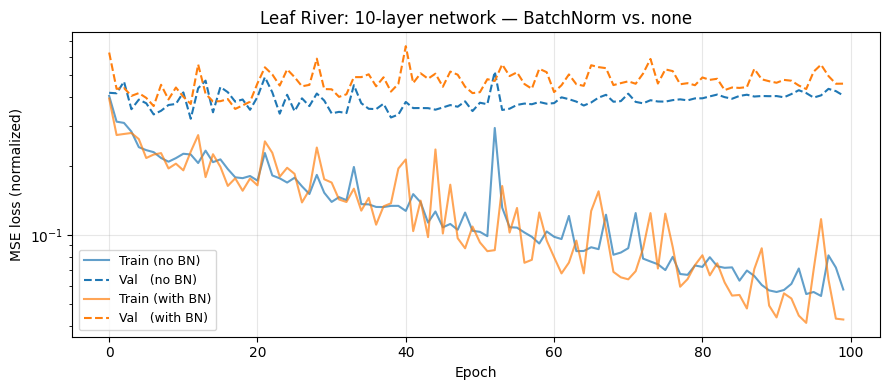

Final validation MSE (normalized):
  Without BatchNorm: 0.40563
  With    BatchNorm: 0.45710

BatchNorm reduces val loss by 0.9×


In [10]:
# 10-layer network on Leaf River: with and without BatchNorm
loader_bn   = DataLoader(
    TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr_norm).reshape(-1, 1)),
    batch_size=128, shuffle=True)
Xv_bn      = torch.tensor(X_vl)
yv_bn_t    = torch.tensor(y_vl_norm).reshape(-1, 1)
Xt_bn_full = torch.tensor(X_tr)
yt_bn_full = torch.tensor(y_tr_norm).reshape(-1, 1)

def make_deep_leaf(use_batchnorm=False, n_hidden=10, width=64):
    layers = []
    sizes  = [n_features] + [width] * n_hidden + [1]
    for i in range(len(sizes) - 1):
        layers.append(nn.Linear(sizes[i], sizes[i+1]))
        if i < len(sizes) - 2:
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(sizes[i+1]))
            layers.append(nn.ReLU())
    return nn.Sequential(*layers)

def train_deep(use_batchnorm=False, epochs=100):
    torch.manual_seed(0)
    model   = make_deep_leaf(use_batchnorm)
    opt     = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()
    tr_losses, vl_losses = [], []
    for _ in range(epochs):
        model.train()
        for xb, yb in loader_bn:
            opt.zero_grad(); loss_fn(model(xb), yb).backward(); opt.step()
        model.eval()   # CRITICAL: switches BatchNorm to running-average mode
        with torch.no_grad():
            tr_losses.append(loss_fn(model(Xt_bn_full), yt_bn_full).item())
            vl_losses.append(loss_fn(model(Xv_bn),      yv_bn_t).item())
    return tr_losses, vl_losses

tr_nobn, vl_nobn = train_deep(use_batchnorm=False)
tr_bn,   vl_bn   = train_deep(use_batchnorm=True)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(tr_nobn, label='Train (no BN)',   color='C0', linestyle='-',  linewidth=1.5, alpha=0.7)
ax.plot(vl_nobn, label='Val   (no BN)',   color='C0', linestyle='--', linewidth=1.5)
ax.plot(tr_bn,   label='Train (with BN)', color='C1', linestyle='-',  linewidth=1.5, alpha=0.7)
ax.plot(vl_bn,   label='Val   (with BN)', color='C1', linestyle='--', linewidth=1.5)
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE loss (normalized)')
ax.set_title('Leaf River: 10-layer network — BatchNorm vs. none')
ax.set_yscale('log'); ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Final validation MSE (normalized):")
print(f"  Without BatchNorm: {vl_nobn[-1]:.5f}")
print(f"  With    BatchNorm: {vl_bn[-1]:.5f}")
print(f"\nBatchNorm reduces val loss by {vl_nobn[-1]/vl_bn[-1]:.1f}×")

Without BatchNorm, the 10-layer network struggles on the Leaf River lag features — the loss barely decreases and the fit is poor. With BatchNorm inserted after each hidden linear layer, training is stable and the network fits the data well.

**When to use it**: Almost always for networks deeper than 5–6 layers, especially CNNs. For time series (RNNs), use **LayerNorm** instead (normalizes across features, not batch). Always remember `model.eval()` before inference to switch from batch statistics to running averages.

## Summary

| Topic | Key rule |
|---|---|
| Data normalization | Standardize inputs; compute statistics on train set only |
| Sanity check | Overfit a single batch before any full training run |
| Reading loss curves | Train/val gap = overfitting; both high = underfitting |
| Weight decay | Add `weight_decay=λ` to Adam; penalizes large weights |
| Dropout | Zeroes random activations during training; `model.eval()` disables it |
| Early stopping | Track val loss; save the checkpoint at the best epoch |
| Temporal leakage | Never shuffle time series; always split by time |
| Class imbalance | Use weighted loss (`pos_weight ≈ N_neg / N_pos`) for rare events |
| Learning rate schedules | Cosine annealing or ReduceLROnPlateau for stable convergence |
| Gradient clipping | `clip_grad_norm_(model.parameters(), max_norm)` — essential for RNNs and deep networks |
| Batch normalization | Insert after linear layers in deep networks (>5 layers); use `model.eval()` at inference |

### Looking ahead

- **Convolutional networks** — exploit spatial structure in gridded fields (SST maps, precipitation fields)
- **Physics-informed neural networks (PINNs)** — embed ODE/PDE residuals directly in the loss; a natural extension of the Newton's method example from the previous notebook
- **Recurrent networks and transformers** — for longer temporal dependencies than a fixed lag window can capture; the natural next step for the Leaf River streamflow problem